In [ ]:
# from preprocessing import get_model_dataset, create_train_test, min_max_scale, df_to_xy, read_file, lag_features
from lstm import create_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from datetime import date
from pathlib import Path

In [ ]:
def read_file(file):
    """Read a single file and return a dataframe"""
    return pd.read_csv(file, skipinitialspace=True)

def lag_features(df, features, seq_length):
    """Transforms a raw 2D dataframe of option data into 2D dataframe ofsequence data.
    Last 2 indexes per sequence are bid and ask price. The len(features)*seq_length
    features before are sequences of features"""
    df = df.sort_values(["Expire_date", "Strike", "Ttl"], ascending = [True, True, False])
    
    # Adding lag for naive benchmarking
    #df["Naive"] = df["Price"].shift(1)

    for step in range(seq_length)[::-1]:
        for feature in features:
            df[feature + "-" + str(step)] = df[feature].shift(step)
    
    df["Check_strike"] = df["Strike"] == df["Strike"].shift(seq_length-1)
    df["Check_expire"] = df["Expire_date"] == df["Expire_date"].shift(seq_length-1)
    df = df[(df["Check_strike"] == True) & (df["Check_expire"] == True)]
    df = df.drop(["Check_strike", "Check_expire"], axis=1)
    #df[["Bid_strike_last", "Ask_strike_last"]] = df[["Bid_strike", "Ask_strike"]]
    #df[["Bid_last", "Ask_last"]] = df[["Bid", "Ask"]]
    df["Price_last"] = df["Price"]
    df = df.sort_values(["Quote_date"], ascending = [True])
    return df

def df_to_xy(df, num_features, seq_length, num_outputs):
    """Transforms a dataframe into two arrays of explanatory variables x and explained variables y"""
    array = df.to_numpy()
    array_x, array_y = array[:, -num_features*seq_length - num_outputs:-num_outputs].astype(np.float32), array[:,-num_outputs:].astype(np.float32)
    return array_x, array_y

In [ ]:
first_year = 2019
last_year = 2021
file = f"../data/processed_data/{first_year}-{last_year}_underlying-strike_only-price.csv"

df_read = read_file(file)
print(df_read)
df_read.info()
print(df_read)
print(df_read["Ttl"].max())

In [ ]:
from datetime import datetime
from dateutil.relativedelta import relativedelta

training_period = 10
val_period = 1
test_period = 1
num_models = 12

features = ["Underlying_last", "Strike", "Ttl", "Volatility", "R"]
seq_length = 5
num_features = len(features)
num_outputs = 1

df_read_lags = lag_features(df_read, features, seq_length)

train_val_test = []

month = 4
year = 0
for i in range(num_models):
    if month == 13:
        year += 1
        month = 1
    train_start = datetime(2020 + year, month, 1)
    val_start = train_start + relativedelta(months=8)
    test_start = val_start + relativedelta(months=1)
    test_end = test_start + relativedelta(months=1)

    month += 1

    df_train_orginal = df_read_lags.loc[(df_read_lags.loc[:, "Quote_date"] >= str(train_start)) & (df_read_lags.loc[:, "Quote_date"] < str(val_start)), :]
    df_val_orginal = df_read_lags.loc[(df_read_lags.loc[:, "Quote_date"] >= str(val_start)) & (df_read_lags.loc[:, "Quote_date"] < str(test_start)), :]
    df_test_orginal = df_read_lags.loc[(df_read_lags.loc[:, "Quote_date"] >= str(test_start)) & (df_read_lags.loc[:, "Quote_date"] < str(test_end)), :]

    train_x_org, train_y_org = df_to_xy(df_train_orginal, num_features, seq_length, num_outputs)
    val_x_org, val_y_org = df_to_xy(df_val_orginal, num_features, seq_length, num_outputs)
    test_x_org, test_y_org = df_to_xy(df_test_orginal, num_features, seq_length, num_outputs)

    scaler = MinMaxScaler()
    train_x_scaled = scaler.fit_transform(train_x_org)
    val_x_scaled = scaler.transform(val_x_org)
    test_x_scaled = scaler.transform(test_x_org)

    print(month, test_x_scaled.shape)
    print(test_start, test_end)

    """shuffle = np.random.permutation(len(train_x_scaled))
    train_x_scaled, train_y_scaled = train_x_scaled[shuffle], train_y_scaled[shuffle]"""

    train_x_scaled = np.reshape(train_x_scaled, (len(train_x_scaled), seq_length, num_features))
    val_x_scaled = np.reshape(val_x_scaled, (len(val_x_scaled), seq_length, num_features))
    test_x_scaled = np.reshape(test_x_scaled, (len(test_x_scaled), seq_length, num_features))

    # print(f"Train_x shape: {train_x_scaled.shape}, train_y shape: {train_y_org.shape}")
    # print(f"Test_x shape: {test_x_scaled.shape}, test_y shape: {test_y_org.shape}")
    # print("------------------------------------------------")
    train_val_test.append(((train_x_scaled, train_y_org), (val_x_scaled, val_y_org), (test_x_scaled, test_y_org)))
    break




In [ ]:
from keras.callbacks import EarlyStopping
import tensorflow as tf

config = {
        "units": 64,
        "learning_rate": 0.002594627161103502,
        "layers": 5,
        "bn_momentum" : 0.26212094315874734,
        "weight_decay": 0.0003327609151101109,
        "seq_length": seq_length,
        "num_features": num_features,
    }

def trainer(train_x, train_y, model, val_x, val_y):
    epochs = 100
    minibatch_size = 4096

    tf.random.set_seed(2)

    early_stopping = EarlyStopping(
        monitor='val_loss',
        mode='min',
        min_delta = 1,
        patience = 5,
    )

    model.fit(
        train_x,
        train_y,
        batch_size = minibatch_size,
        # validation_split = 0.3,
        validation_data = (val_x, val_y),
        epochs = epochs,
        callbacks = [early_stopping]
    )

predictions = []
for i, ((x_train, y_train), (x_val, y_val), (x_test, y_test)) in enumerate(train_val_test):
    # if i == 8:
    model = create_model(config)
    model.summary()
    trainer(x_train, y_train, model, x_val, y_val)

    predictions.append(np.array(model(x_test)))

predictions = np.concatenate(predictions)


path = f"../data/models/new_model_LSTM.keras"
model.save(path)

In [ ]:
from tensorflow.keras.models import load_model

# Load your trained model (or create one)
model = load_model('../data/models/new_model_LSTM.keras')


In [ ]:
import shap
import numpy as np

background = x_train[np.random.choice(x_train.shape[0], 1000, replace=False)]

explainer = shap.GradientExplainer(model, background)

data_to_explain = x_test

shap_values = explainer.shap_values(data_to_explain)
np.save('shap_values.npy', shap_values)


In [ ]:
shap_values = np.load('shap_values.npy')
shap_values_reshaped = shap_values.reshape(shap_values.shape[0], -1)
x_test_reshaped = x_test.reshape(x_test.shape[0], -1)
feature_names = [
    "S&P500-4", "Strike-4", "Time to maturity-4", "Volatility-4", "Risk-free rate-4",
    "S&P500-3", "Strike-3", "Time to maturity-3", "Volatility-3", "Risk-free rate-3",
    "S&P500-2", "Strike-2", "Time to maturity-2", "Volatility-2", "Risk-free rate-2",
    "S&P500-1", "Strike-1", "Time to maturity-1", "Volatility-1", "Risk-free rate-1",
    "S&P500-0", "Strike-0", "Time to maturity-0", "Volatility-0", "Risk-free rate-0",
    ]

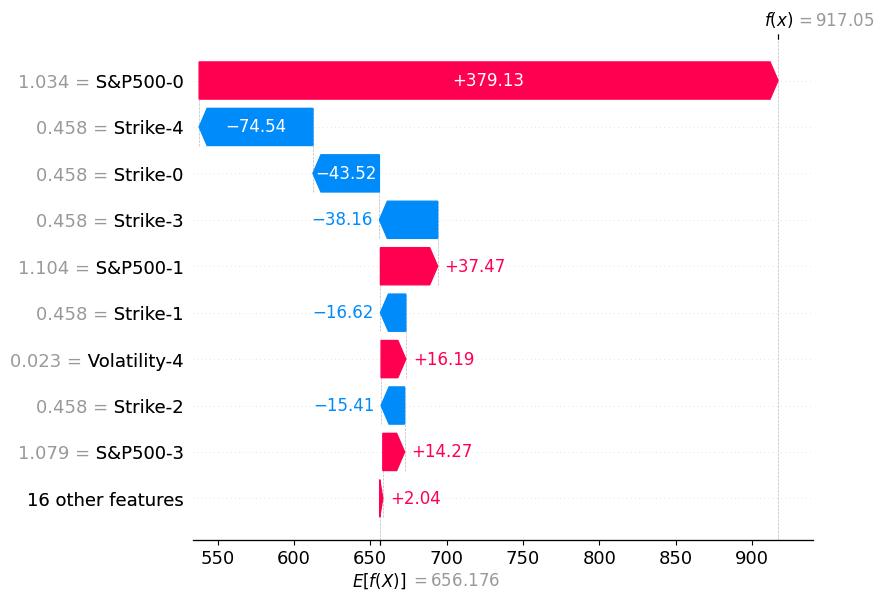

In [107]:
expected_value = y_test.mean()
feature_values = x_test_reshaped[0] 

explanation = shap.Explanation(
    values=shap_values_reshaped[0], 
    base_values=expected_value, 
    data=feature_values,
    feature_names=feature_names
)

shap.waterfall_plot(explanation)

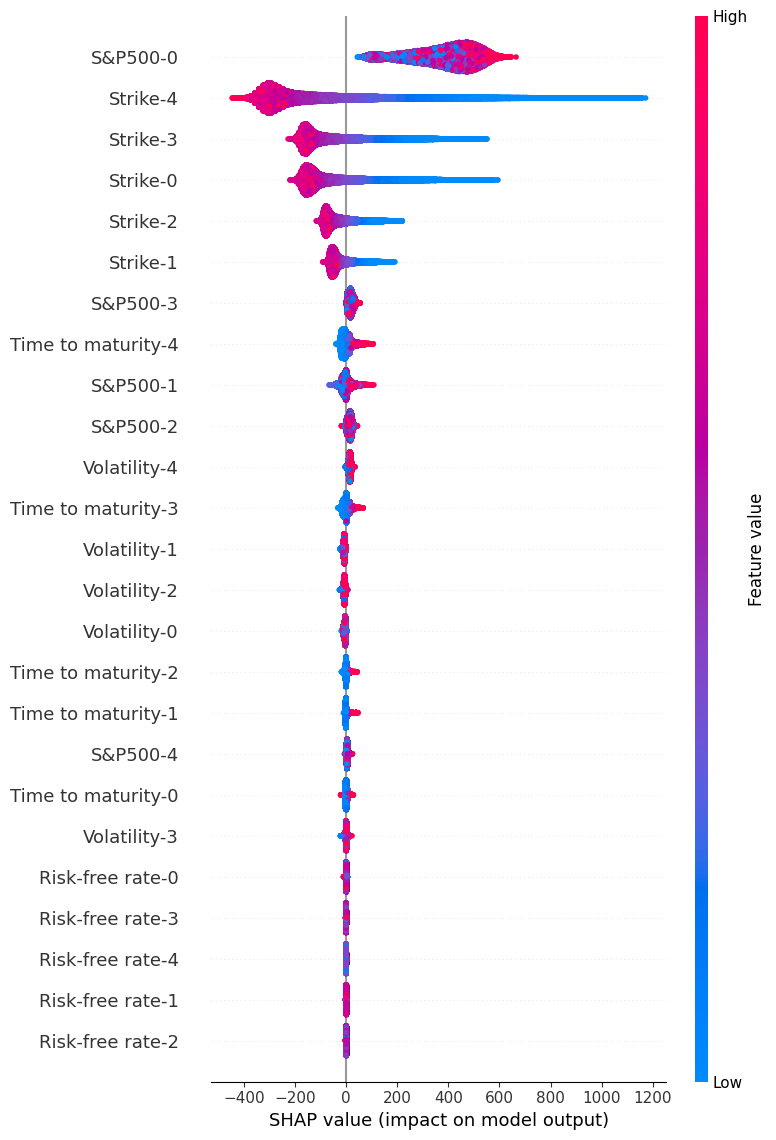

In [106]:
expected_value = y_test.mean()

x_test_reshaped = x_test.reshape(x_test.shape[0], -1)
feature_values = x_test_reshaped


explanation = shap.Explanation(
    values=shap_values_reshaped, 
    base_values=expected_value, 
    data=feature_values,
    feature_names=feature_names
)

shap.summary_plot(explanation, max_display=25)

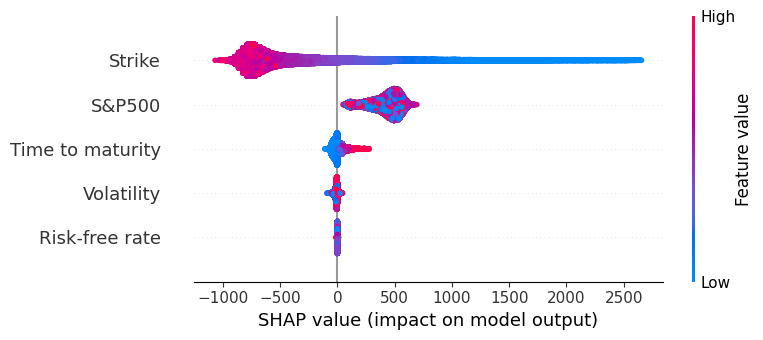

In [95]:
import numpy as np
import shap

# Example: Assume you have 5 features with 5 lags each (so 25 in total)
n_features = 5
n_lags = 5

# Reshape SHAP values to (n_samples, n_features, n_lags)
shap_values_reshaped_for_agg = shap_values.reshape(-1, n_features, n_lags)

# Sum SHAP values over lags (axis=2 sums over the lags)
shap_values_aggregated = np.sum(shap_values_reshaped_for_agg, axis=1)

# Update feature names to only include distinct features
# distinct_feature_names = [name.split('_lag')[0] for name in feature_names[:n_features * n_lags:n_lags]]
distinct_feature_names = ["S&P500", "Strike", "Time to maturity", "Volatility", "Risk-free rate"]
# distinct_feature_names = distinct_feature_names[::-1]

# Create a new SHAP explanation object with aggregated values
aggregated_explanation = shap.Explanation(
    values=shap_values_aggregated,  # Aggregated SHAP values
    base_values=expected_value,  # Same expected value
    data=x_test_reshaped[:, :n_features],  # First `n_features` data columns (ignoring lags)
    feature_names=distinct_feature_names  # Use distinct feature names without lags
)

# Plot the summary plot with the aggregated SHAP values
shap.summary_plot(aggregated_explanation, max_display=n_features, show=False)
plt.savefig("../data/Results/summary_plot_agg.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

# from matplotlib import cm
# cmaps = ['Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'viridis', 'viridis_r', 'winter', 'winter_r']
# counter = 14
# print(len(cmaps))
# for i in range(5*counter, counter*5 + 5):
#     cmap = cmaps[i]
#     shap.summary_plot(aggregated_explanation, max_display=n_features, cmap=cmap)


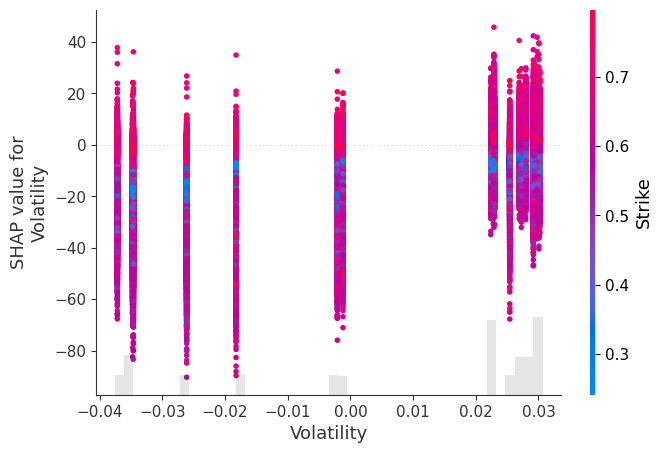

In [96]:
aggregated_explanation = shap.Explanation(
    values=shap_values_aggregated,  
    base_values=expected_value,  
    data=x_test_reshaped[:, :n_features],  
    feature_names=distinct_feature_names 
)
shap.plots.scatter(aggregated_explanation[:, "Volatility"], color=aggregated_explanation[:, "Strike"], show=False)
plt.savefig("../data/Results/vol_strike_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

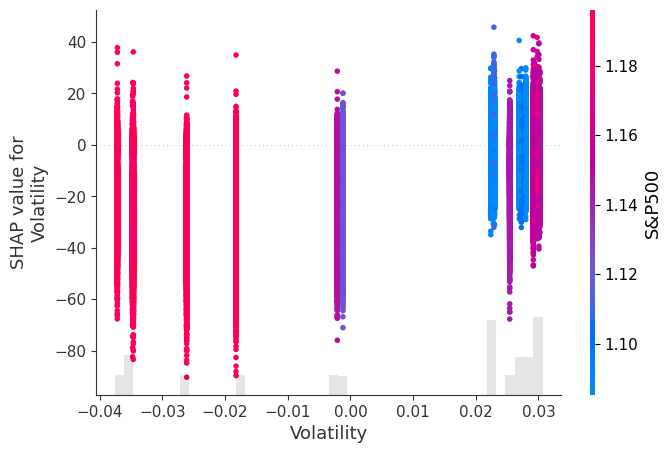

In [97]:
shap.plots.scatter(aggregated_explanation[:, "Volatility"], color=aggregated_explanation[:, "S&P500"], show=False)
plt.savefig("../data/Results/vol_sp500_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

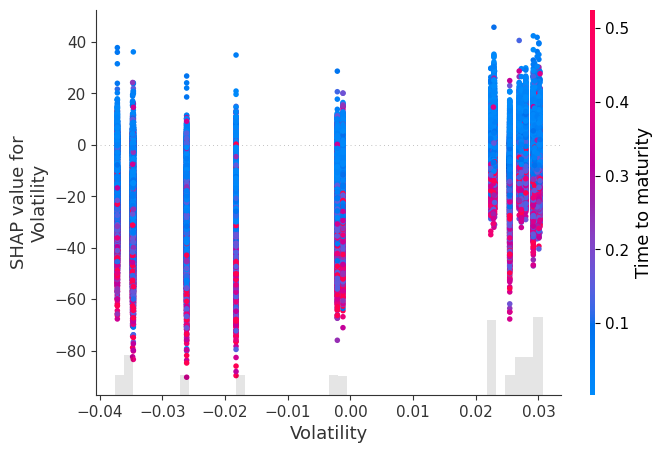

In [98]:
shap.plots.scatter(aggregated_explanation[:, "Volatility"], color=aggregated_explanation[:, "Time to maturity"], show=False)
plt.savefig("../data/Results/vol_ttl_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

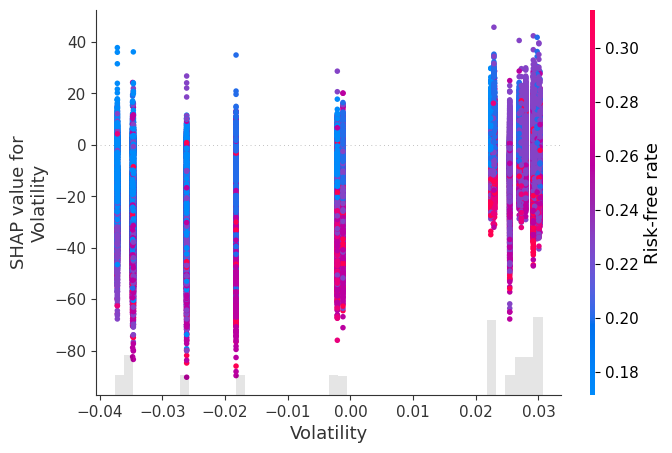

In [99]:
shap.plots.scatter(aggregated_explanation[:, "Volatility"], color=aggregated_explanation[:, "Risk-free rate"], show=False)
plt.savefig("../data/Results/vol_rf_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

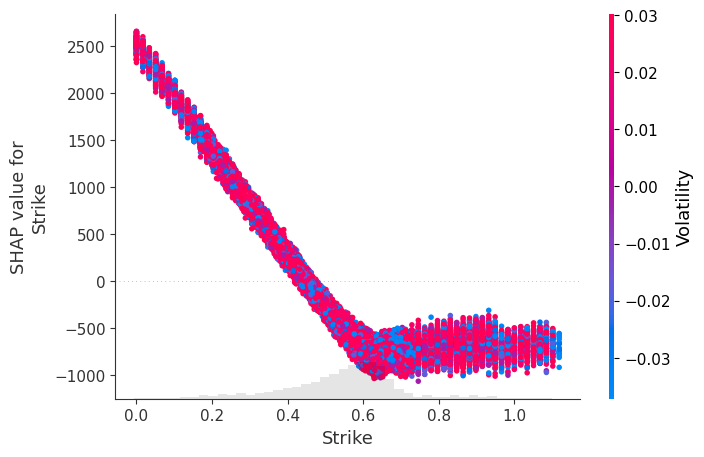

In [100]:
shap.plots.scatter(aggregated_explanation[:, "Strike"], color=aggregated_explanation[:, "Volatility"], show=False)
plt.savefig("../data/Results/strike_vol_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

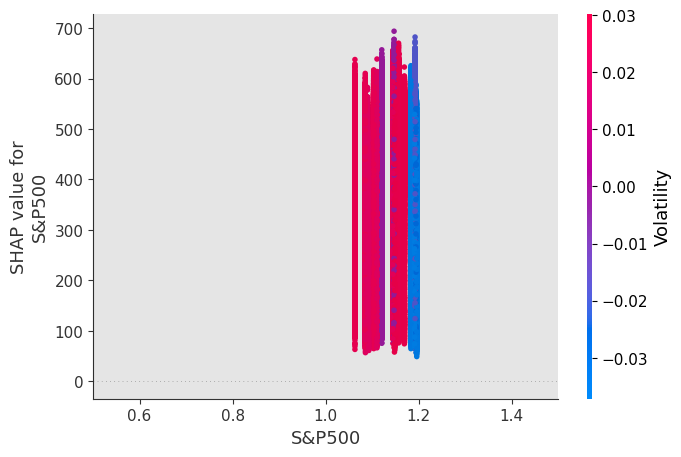

In [101]:
shap.plots.scatter(aggregated_explanation[:, "S&P500"], color=aggregated_explanation[:, "Volatility"], show=False)
plt.savefig("../data/Results/sp500_vol_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
shap.plots.scatter(aggregated_explanation[:, "Time to maturity"], color=aggregated_explanation[:, "Volatility"], show=False)
plt.savefig("../data/Results/ttl_vol_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
shap.plots.scatter(aggregated_explanation[:, "Risk-free rate"], color=aggregated_explanation[:, "Volatility"], show=False)
plt.savefig("../data/Results/rf_vol_scatter.png", format='png', dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
explanation = shap.Explanation(
    values=shap_values_reshaped, 
    base_values=expected_value, 
    data=feature_values,
    feature_names=feature_names
)
shap.plots.scatter(explanation[:, "S&P500-0"], color=explanation[:, "Strike-0"])


In [ ]:
shap.dependence_plot("S&P500-0", shap_values_reshaped, x_test_reshaped, interaction_index="Volatility-0", feature_names=feature_names)

In [ ]:
shap.dependence_plot("S&P500-0", shap_values_reshaped, x_test_reshaped, interaction_index="Time to maturity-0", feature_names=feature_names)

In [ ]:
shap.dependence_plot("Time to maturity-4", shap_values_reshaped, x_test_reshaped, interaction_index="Volatility-4", feature_names=feature_names)

In [ ]:
shap.dependence_plot("Volatility-4", shap_values_reshaped, x_test_reshaped, interaction_index="Time to maturity-4", feature_names=feature_names)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

shap_values_reshaped_for_agg = shap_values.reshape(-1, n_features, n_lags)
shap_values_aggregated = np.sum(shap_values_reshaped_for_agg, axis=1)
distinct_feature_names = ["S&P500", "Strike", "Time to maturity", "Volatility", "Risk-free rate"]
x_test_agg = x_test_reshaped[:, :n_features]
x_test_agg = pd.DataFrame(data=x_test_agg, columns=distinct_feature_names)

shap_value_columns = ["Shap values for S&P500", "Shap values for Strike", "Shap values for Time to maturity", "Shap values for Volatility", "Shap values for Risk-free rate"]

x_test_agg[shap_value_columns] = shap_values_aggregated



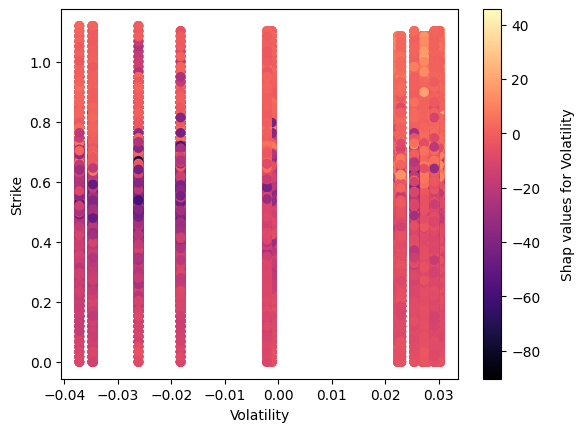

In [102]:
x_label = "Volatility"
y_label = "Strike"
z_label = "Shap values for Volatility"

# Assuming your DataFrame is called df
x = x_test_agg.loc[:, x_label]  # First column as x-axis
y = x_test_agg.loc[:, y_label]  # Second column as y-axis
c = x_test_agg.loc[:, z_label]  # Third column as color

colors = ['#3498db', '#8e44ad', '#e74c3c'] 
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=100)

# Create the scatter plot
scatter = plt.scatter(x, y, c=c, cmap="magma")  # 'viridis' colormap, change if needed

# Add color bar and set the label
cbar = plt.colorbar(scatter)
cbar.set_label(z_label, rotation=90, labelpad=15)  # Adjust the label and its position

# Add labels and title for the plot
plt.xlabel(x_label)
plt.ylabel(y_label)

plt.savefig("../data/Results/vol_strike_scatter_custom.png", format='png', dpi=300, bbox_inches='tight') 

plt.show()


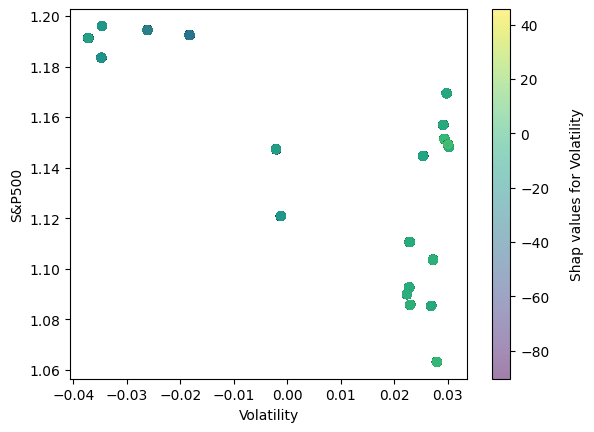

In [109]:
x_label = "Volatility"
y_label = "S&P500"
z_label = "Shap values for Volatility"

# Assuming your DataFrame is called df
x = x_test_agg.loc[:, x_label]  # First column as x-axis
y = x_test_agg.loc[:, y_label]  # Second column as y-axis
c = x_test_agg.loc[:, z_label]  # Third column as color

colors = ['#3498db', '#8e44ad', '#e74c3c'] 
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=100)

# Create the scatter plot
scatter = plt.scatter(x, y, c=c, cmap="viridis")  # 'viridis' colormap, change if needed

# Add color bar and set the label
cbar = plt.colorbar(scatter)
cbar.set_label(z_label, rotation=90, labelpad=15)  # Adjust the label and its position

# Add labels and title for the plot
plt.xlabel(x_label)
plt.ylabel(y_label)

plt.savefig("../data/Results/vol_sp500_scatter_custom.png", format='png', dpi=300, bbox_inches='tight') 

plt.show()


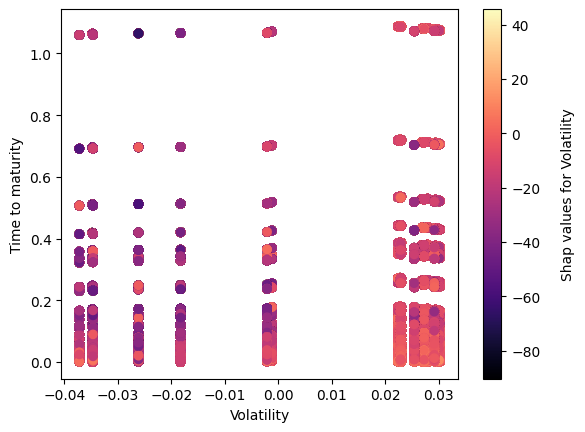

In [104]:
x_label = "Volatility"
y_label = "Time to maturity"
z_label = "Shap values for Volatility"

# Assuming your DataFrame is called df
x = x_test_agg.loc[:, x_label]  # First column as x-axis
y = x_test_agg.loc[:, y_label]  # Second column as y-axis
c = x_test_agg.loc[:, z_label]  # Third column as color

colors = ['#3498db', '#8e44ad', '#e74c3c'] 
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=100)

# Create the scatter plot
scatter = plt.scatter(x, y, c=c, cmap="magma")  # 'viridis' colormap, change if needed

# Add color bar and set the label
cbar = plt.colorbar(scatter)
cbar.set_label(z_label, rotation=90, labelpad=15)  # Adjust the label and its position

# Add labels and title for the plot
plt.xlabel(x_label)
plt.ylabel(y_label)

plt.savefig("../data/Results/vol_ttl_scatter_custom.png", format='png', dpi=300, bbox_inches='tight') 

plt.show()


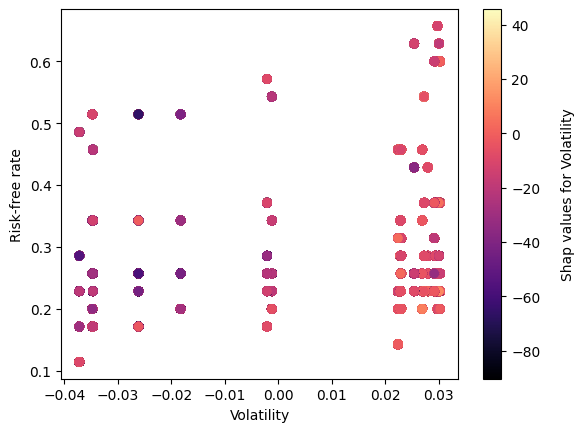

In [105]:
x_label = "Volatility"
y_label = "Risk-free rate"
z_label = "Shap values for Volatility"

# Assuming your DataFrame is called df
x = x_test_agg.loc[:, x_label]  # First column as x-axis
y = x_test_agg.loc[:, y_label]  # Second column as y-axis
c = x_test_agg.loc[:, z_label]  # Third column as color

colors = ['#3498db', '#8e44ad', '#e74c3c'] 
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=100)

# Create the scatter plot
scatter = plt.scatter(x, y, c=c, cmap="magma")  # 'viridis' colormap, change if needed

# Add color bar and set the label
cbar = plt.colorbar(scatter)
cbar.set_label(z_label, rotation=90, labelpad=15)  # Adjust the label and its position

# Add labels and title for the plot
plt.xlabel(x_label)
plt.ylabel(y_label)

plt.savefig("../data/Results/vol_rf_scatter_custom.png", format='png', dpi=300, bbox_inches='tight') 

plt.show()


In [ ]:
# print(x_test_reshaped[10000:10010, 20])
# print(x_test_reshaped[:, 20].unique())
print(np.unique(x_test_reshaped[:, 20]).shape)
print(np.unique(x_test_reshaped[:, 21]).shape)
print(np.unique(x_test_reshaped[:, 22]).shape)
print(np.unique(x_test_reshaped[:, 23]).shape)
print(np.unique(x_test_reshaped[:, 24]).shape)
print(x_test_reshaped.shape)
print(487*305)